In [2]:
!pip install -q --upgrade kaggle

import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("mkk")

print("Kaggle credentials loaded successfully.")

Kaggle credentials loaded successfully.


In [3]:
!mkdir -p /content/data

!kaggle datasets download talhasar/genki4k  -p /content/data

print("Dataset downloaded.")

Dataset URL: https://www.kaggle.com/datasets/talhasar/genki4k
License(s): CC-BY-NC-SA-4.0
100% 25.0M/25.0M [00:00<00:00, 81.5MB/s]

Dataset downloaded.


In [4]:
import zipfile
import os

zip_path = "/content/data/genki4k.zip"
extract_path = "/content/data/genki4k_extracted"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/data/genki4k_extracted


In [5]:
import os

extracted_dataset_path = "/content/data/genki4k_extracted"

# List contents of the extracted directory
print("Contents of the extracted dataset:")
for root, dirs, files in os.walk(extracted_dataset_path):
    level = root.replace(extracted_dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of the extracted dataset:
genki4k_extracted/
    kaggle-genki4k/
        smile/
            file1879.jpg
            file1963.jpg
            file1782.jpg
            file0018.jpg
            file0597.jpg
            file1018.jpg
            file0050.jpg
            file2140.jpg
            file0758.jpg
            file2135.jpg
            file1878.jpg
            file1248.jpg
            file0197.jpg
            file1176.jpg
            file0377.jpg
            file0194.jpg
            file1683.jpg
            file1568.jpg
            file1965.jpg
            file0588.jpg
            file1065.jpg
            file1287.jpg
            file1236.jpg
            file1257.jpg
            file2025.jpg
            file0750.jpg
            file2048.jpg
            file0117.jpg
            file2107.jpg
            file0713.jpg
            file0938.jpg
            file0914.jpg
            file1473.jpg
            file1342.jpg
            file0211.jpg
            file0091.jpg
           

This will show us the structure of the dataset. Look for a `README.md` file or any CSVs/JSONs that might contain metadata about the dataset.

In [6]:
import os

base_dir = "/content/data/genki4k_extracted/kaggle-genki4k"

print(os.listdir(base_dir))

print(
    "Smile:",
    len(os.listdir(os.path.join(base_dir,"smile")))
)

print(
    "Non-Smile:",
    len(os.listdir(os.path.join(base_dir,"non_smile")))
)

['smile', 'non_smile']
Smile: 2162
Non-Smile: 1838


In [7]:
import os
import tensorflow as tf

dataset_path = "/content/data/genki4k_extracted/kaggle-genki4k"

bad_files = []

for root, _, files in os.walk(dataset_path):
    for file in files:

        path = os.path.join(root,file)

        try:
            img = tf.io.read_file(path)
            tf.io.decode_image(img, channels=3)

        except Exception:
            print("Bad file:", path)
            bad_files.append(path)


print("Total bad files:", len(bad_files))

Total bad files: 0


In [8]:
import os

for file in bad_files:
    os.remove(file)
    print("Deleted:", file)

print("Cleaning completed.")

Cleaning completed.


In [9]:
from tensorflow import keras


train_ds = keras.utils.image_dataset_from_directory(
    "/content/data/genki4k_extracted/kaggle-genki4k",

    validation_split=0.2,
    subset="training",

    seed=42,

    image_size=(150,150),
    batch_size=32)



validation_ds = keras.utils.image_dataset_from_directory(
    "/content/data/genki4k_extracted/kaggle-genki4k",

    validation_split=0.2,
    subset="validation",

    seed=42,

    image_size=(150,150),
    batch_size=32
)


print(train_ds.class_names)

Found 4000 files belonging to 2 classes.
Using 3200 files for training.
Found 4000 files belonging to 2 classes.
Using 800 files for validation.
['non_smile', 'smile']


In [10]:
import tensorflow as tf


train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(validation_ds).numpy()


print("Training batches:", train_batches)
print("Validation batches:", val_batches)


print("Training images:", train_batches*32)
print("Validation images:", val_batches*32)

Training batches: 100
Validation batches: 25
Training images: 3200
Validation images: 800


In [11]:
from tensorflow import keras
from keras import layers


data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

    layers.RandomContrast(0.1)

])

In [12]:
from tensorflow.keras.applications.vgg16 import preprocess_input


def process(image,label):

    image = preprocess_input(image)

    return image,label



train_ds = train_ds.map(process)

validation_ds = validation_ds.map(process)



train_ds = train_ds.map(
    lambda x,y:
    (data_augmentation(x,training=True),y)
)

In [13]:
AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(AUTOTUNE)

validation_ds = validation_ds.prefetch(AUTOTUNE)

In [14]:
from tensorflow.keras.applications import VGG16


conv_base = VGG16(

    weights="imagenet",

    include_top=False,

    input_shape=(150,150,3)

)


conv_base.trainable=False


conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
conv_base.trainable = True

set_trainable = False # Initialize set_trainable flag

for layer in conv_base.layers:
    if layer.name == "block5_conv1": # Use layer.name to check the current layer's name
      set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in conv_base.layers:
    print(layer.name, layer.trainable)

input_layer_1 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [17]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)


model = Sequential([

    conv_base,

    GlobalAveragePooling2D(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )

])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 7,211,009 (27.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [18]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [19]:
history = model.fit(

    train_ds,

    epochs=10,

    validation_data=validation_ds

)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 306ms/step - accuracy: 0.5250 - loss: 1.0127 - val_accuracy: 0.5487 - val_loss: 0.6887
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 307ms/step - accuracy: 0.5384 - loss: 0.6905 - val_accuracy: 0.5487 - val_loss: 0.6886
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 306ms/step - accuracy: 0.5384 - loss: 0.6905 - val_accuracy: 0.5487 - val_loss: 0.6885
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 303ms/step - accuracy: 0.5384 - loss: 0.6903 - val_accuracy: 0.5487 - val_loss: 0.6884
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 302ms/step - accuracy: 0.5394 - loss: 0.7038 - val_accuracy: 0.5487 - val_loss: 0.6885
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 303ms/step - accuracy: 0.5372 - loss: 0.6957 - val_accuracy: 0.5487 - val_loss: 0.6885
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 302ms/step - accuracy: 0.5384 - loss: 0.6905 - val_accuracy: 0.5487 - val_loss: 0.6885
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 307ms/step - accuracy: 0.5384 - loss: 0

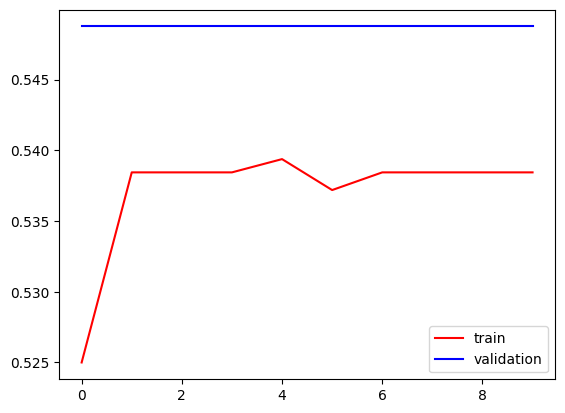

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

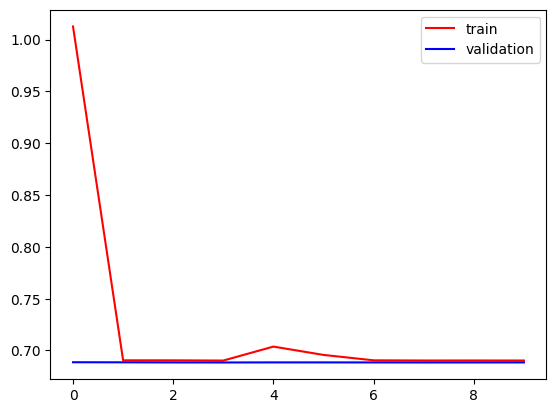

In [21]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()